In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from helper_functions.helper_functions import *
from data.data_operators import BScanDepthDataset,ComposeBScanTransforms
from networks.Unets import BnetSmallKernelSmarterRefine,BnetMean
from torch.utils.data import DataLoader
from tqdm import tqdm
from pulse_method.toolbox_pulse import *

In [2]:
sim=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001.npz",allow_pickle=True)
experiment=np.load('/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/data/2026_03_18_CFRP_FBH_5s_30s_top_symetrical.npz',allow_pickle=True)

Text(0.5, 1.0, 'Experimental data')

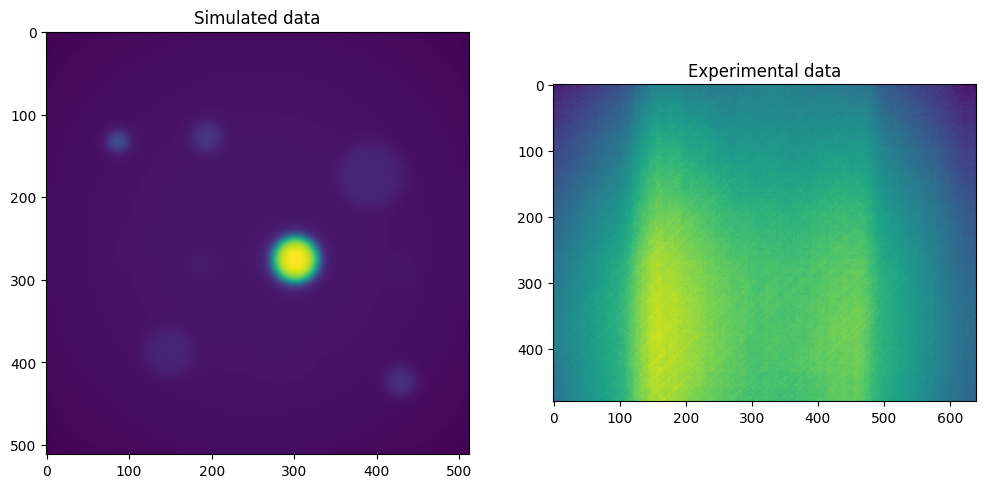

In [3]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(sim['data'][100,:,:])
plt.title('Simulated data')

plt.subplot(1,2,2)
plt.imshow(experiment['data'][100,:,:])
plt.title('Experimental data')

Text(0, 0.5, 'Delta Temperature (°C)')

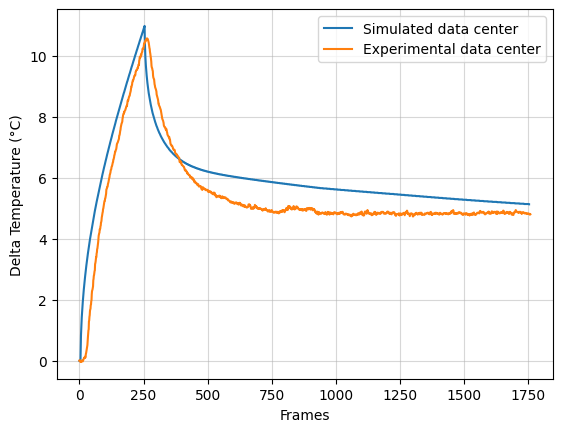

In [43]:

exp_c=experiment['data'][:,240,320]/100-273.15

plt.plot(sim['data'][:,256,256]-20,label='Simulated data center')
plt.plot(exp_c-exp_c[0:4].mean(),label='Experimental data center')
plt.grid(alpha=0.5)
plt.legend()
plt.xlabel('Frames')
plt.ylabel('Delta Temperature (°C)')

In [4]:
operator=thermograms(height=480,width=640)

In [ ]:
phase,mag=operator.PPT(experiment['data'])


In [15]:
Eofs,_=operator.PCT(experiment['data'],n_components=10)

Text(0.5, 1.0, 'EOF of PCT')

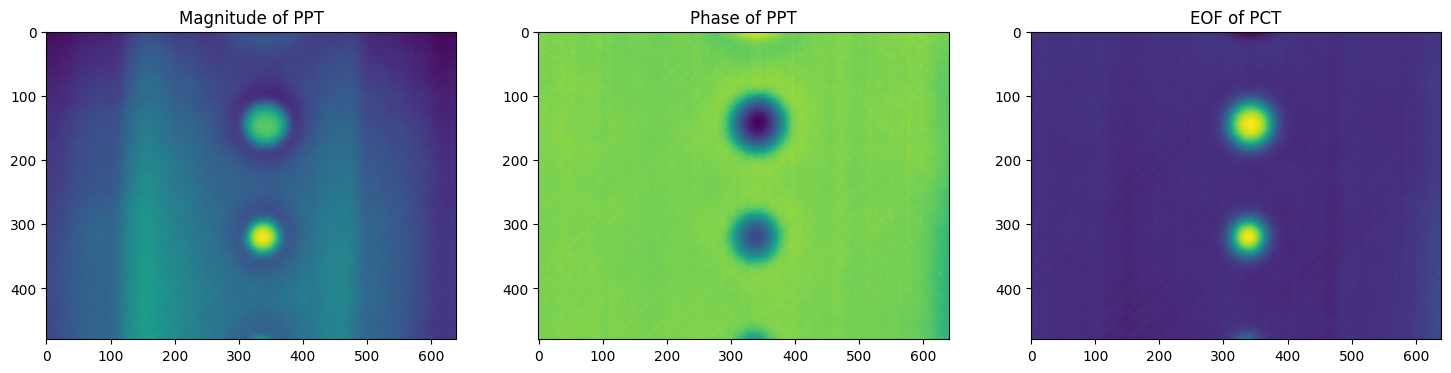

In [42]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.imshow(mag[1,:,:])
plt.title('Magnitude of PPT')

plt.subplot(1,3,2)
plt.imshow(phase[1,:,:])
plt.title('Phase of PPT')

plt.subplot(1,3,3)
plt.imshow(Eofs[1,:,:])
plt.title('EOF of PCT')
